<a href="https://colab.research.google.com/github/raven-in-space/data-science-cohort-20/blob/main/Project-5/NLP_Wikipedia_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 5: Natural Language Processing
**Application of NLP from Lectures and AI: A Comparison**

In this project, I explore the application of **Natural Language Processing** in three parts:
1. Identifying the 10 most similar people to a famous person of choice using TF-IDF and sentiment analysis;
2. Determine K-Nearest Neighbor ranking using the Wikipedia API and visual plots;
3. Making an interactive notebook to rank the most similar persons.

We begin with some handy code granted by the instructor:

In [33]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"

In [34]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [35]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n

     1	URI
     2	name
     3	text


In [36]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n

     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

### Part 1)



In this section, I've randomly selected a person from the dataframe using the most iconic number in New Mexico: `505`.

As luck would have it, this random person is a musician!

In [37]:
import nltk
import pandas as pd
import numpy as np
from textblob import TextBlob
from transformers import MarianMTModel, MarianTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

In [38]:
orig_dat = pd.read_csv(url) #, index_col = 0)
orig_dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [39]:
orig_dat.head()

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


Next, we fit the `TF-IDF` model to find the nearest neighbors to Fillipo:

In [40]:
## fit tfidf
tf_idf = TfidfVectorizer(stop_words = 'english')
tf_idf_matrix = tf_idf.fit_transform(orig_dat['text'])

## fit nearest neighbor
nn = NearestNeighbors().fit(tf_idf_matrix)

In [41]:
## select person
person = orig_dat['text'].iloc[505]

## fit person
person_tf_idf = tf_idf.transform([person])

In [42]:
## distances and indices
distances, indices = nn.kneighbors(
  X = person_tf_idf, # person of interest
  n_neighbors = 11, # 11 since person of interest also in the matrix
)

In [43]:
indices

array([[  505, 13914, 32559, 20157,  4974, 23304, 27463,  2551, 37086,
         2341,  8184]])

Next, we investigate the sentiment of Fillipo:

In [44]:
test_blob = TextBlob(person)
test_blob.sentiment

Sentiment(polarity=0.10084670231729057, subjectivity=0.3161764705882353)

Fillipo's biography leans positive with a polarity score of `0.10` and a subjectivity score of `0.316`.

How does this compare to the others? We apply the `TextBlob` `sentiment` method to investigate:

In [45]:
df_indices = orig_dat.iloc[indices[0]].sort_values(by='name')
df_indices

,URI,name,text
27463,<http://dbpedia.org/resource/Andrew_Weiss_(gui...,Andrew Weiss (guitarist),error the wikify template is deprecated and ha...
2341,<http://dbpedia.org/resource/Bob_Both>,Bob Both,bob both born 1952 is an american recording en...
2551,<http://dbpedia.org/resource/Butch_Taylor>,Butch Taylor,butch taylor born clarence francis taylor on a...
8184,<http://dbpedia.org/resource/Dan_Siegel_(music...,Dan Siegel (musician),dan siegel born in seattle washington is a pia...
505,<http://dbpedia.org/resource/Filippo_Gaetani>,Filippo Gaetani,filippo gaetani is a composer record producer ...
37086,<http://dbpedia.org/resource/James_Hoover>,James Hoover,james hoover february 28 1971 in morgantown we...
32559,<http://dbpedia.org/resource/John_Burns_(audio...,John Burns (audio engineer),john burns is a british recording engineer bes...
20157,<http://dbpedia.org/resource/Oliver_Hartmann>,Oliver Hartmann,oliver hartmann born june 28 1970 in rsselshei...
13914,<http://dbpedia.org/resource/Paul_Goldberg_(mu...,Paul Goldberg (musician),paul goldberg born april 25 1959 is an america...
4974,<http://dbpedia.org/resource/Simone_Sello>,Simone Sello,simone sello born july 4 1968 is an italian bo...


In [46]:
# semantic scores
for index, row in df_indices.iterrows():
    name = row["name"]
    text = row["text"]
    blob = TextBlob(str(text))

    sentiment_score = blob.sentiment
    print(f"{name} has a score of: \n{sentiment_score}\n")

Andrew Weiss (guitarist) has a score of: 
Sentiment(polarity=0.09143385070214338, subjectivity=0.3472025129342203)

Bob Both has a score of: 
Sentiment(polarity=0.1402121781727045, subjectivity=0.3920146958304852)

Butch Taylor has a score of: 
Sentiment(polarity=0.12363636363636361, subjectivity=0.33499999999999996)

Dan Siegel (musician) has a score of: 
Sentiment(polarity=0.18787878787878787, subjectivity=0.40629734848484844)

Filippo Gaetani has a score of: 
Sentiment(polarity=0.10084670231729057, subjectivity=0.3161764705882353)

James Hoover has a score of: 
Sentiment(polarity=0.00535353535353535, subjectivity=0.3327777777777778)

John Burns (audio engineer) has a score of: 
Sentiment(polarity=0.10402837902837903, subjectivity=0.3716625966625967)

Oliver Hartmann has a score of: 
Sentiment(polarity=0.10266955266955267, subjectivity=0.3302669552669553)

Paul Goldberg (musician) has a score of: 
Sentiment(polarity=0.2438954545454547, subjectivity=0.4804606060606061)

Simone Sello h

### Part 2)



Not bad! How does this compare to the *entire* Wikipedia article?

In this section, we apply cleaning methods and use the Wikipedia API to fully explore similarity of persons using `TF-IDF` and `K-means clustering`.

In [47]:
#install Wikipedia API
!pip3 install wikipedia-api

In [48]:
import wikipediaapi as wiki
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# create copy
df_main = df_indices.copy()
df_main

# remove fillipo
df_similar = df_main.drop(505)
df_similar

,URI,name,text
27463,<http://dbpedia.org/resource/Andrew_Weiss_(gui...,Andrew Weiss (guitarist),error the wikify template is deprecated and ha...
2341,<http://dbpedia.org/resource/Bob_Both>,Bob Both,bob both born 1952 is an american recording en...
2551,<http://dbpedia.org/resource/Butch_Taylor>,Butch Taylor,butch taylor born clarence francis taylor on a...
8184,<http://dbpedia.org/resource/Dan_Siegel_(music...,Dan Siegel (musician),dan siegel born in seattle washington is a pia...
37086,<http://dbpedia.org/resource/James_Hoover>,James Hoover,james hoover february 28 1971 in morgantown we...
32559,<http://dbpedia.org/resource/John_Burns_(audio...,John Burns (audio engineer),john burns is a british recording engineer bes...
20157,<http://dbpedia.org/resource/Oliver_Hartmann>,Oliver Hartmann,oliver hartmann born june 28 1970 in rsselshei...
13914,<http://dbpedia.org/resource/Paul_Goldberg_(mu...,Paul Goldberg (musician),paul goldberg born april 25 1959 is an america...
4974,<http://dbpedia.org/resource/Simone_Sello>,Simone Sello,simone sello born july 4 1968 is an italian bo...
23304,<http://dbpedia.org/resource/Steff_Fontaine>,Steff Fontaine,stephen steff fontaine is an american rock sin...


First, let's print out the text of the Wikipedia article for Filippo Gaetani:

In [50]:
fillipo_orig = orig_dat['name'].iloc[505]
wikip = wiki.Wikipedia(user_agent = 'foobar')
fillipo_page_ex = wikip.page(fillipo_orig)
fillipo_wiki = fillipo_page_ex.text
fillipo_wiki

'Filippo Gaetani is a composer, record producer, engineer and musician.\nActive since the mid-1980s, he started working as arranger, bassist and guitarist for several underground jazz-rock bands and performing live with his band in northern Italy supporting important Italian live acts such as PFM, Ivano Fossati and Skiantos. After joining  Gianluca Mosole band as vocalist, percussionist and co-producer, he performed an entire summer tour supporting acts like Sting, Gil Evans, Miles Davis and Al Di Meola.\nIn the 1990s, started his work as engineer and producer, recording over 40 jazz-pop-rock albums of Italian and international acts and writing music for TV and writing and recording in Ennio Morricone studio Forum in Rome\nfor the original soundtrack for the movie "Ritorno a Parigi". His collaborations and productions include Stefano Bollani, Andy Bell/Philip Larsen, Katja Werker, Don Grusin, Adrina Thorpe, My Excellence, Erik Friedlander, Tessa Drummond, Peter Doran, Martin Klein, Pap

Let's clean and determine the sentiment:

In [51]:
fillipo_wiki_clean = (
    fillipo_wiki
    .lower()
    .replace("\n"," ")
    .replace("\'s",'')
    .replace('\'','')
    .replace("(", "")
    .replace(")", "")
    .replace('"', "")
  )

fillipo_blob = TextBlob(fillipo_wiki_clean)
fillipo_blob.sentiment

Sentiment(polarity=0.08321371610845296, subjectivity=0.3197368421052631)

We notice a slight change from the original sentiment score at `0.10` when the text was... just a blurb.

Let's take a look at the other similar persons of interest:

In [52]:
results = []

for index, row in df_similar.iterrows():
  name = row['name']
  page_ex = wikip.page(name)
  wiki_text = page_ex.text

  print(f"Name: '{name}'")
  print(f"Wikipedia: {wiki_text[:200]}...\n") # first 200 chars only

Name: 'Andrew Weiss (guitarist)'
Wikipedia: Andrew Weiss is an American musician, composer, audio engineer and record producer.

Life and career
Born in Chicago, Weiss spent most of his youth growing up in central New Jersey where he later star...

Name: 'Bob Both'
Wikipedia: Bob Both (born 1952) is an American recording engineer and record producer, best known for his work with James Brown in the 1970s.
Both was born in Bloomfield, New Jersey, the son of a carpenter, Jake...

Name: 'Butch Taylor'
Wikipedia: Butch Taylor (born Clarence Francis Taylor on April 13, 1961) is a composer, writer, keyboardist and long time guest musician with Dave Matthews Band.

Early life
Butch Taylor was born in Shawsville, ...

Name: 'Dan Siegel (musician)'
Wikipedia: Dan Siegel (born in Seattle, Washington) is an American pianist, composer, and record producer. His earlier music has been described as new age, while his more recent work has been called contemporary...

Name: 'James Hoover'
Wikipedia: Jam

Looks like there's some weirdness going on, such as in the case of `Steff Fontaine`. We'll have to look at it later due to time constraints.

Next, let's take a look at the sentiment for each article:

In [53]:
sentiment_results = []

for index, row in df_similar.iterrows():
  name = row['name']
  page_ex = wikip.page(name)
  wiki_text = page_ex.text

  wiki_text_clean = (
      wiki_text
      .lower()
      .replace("\n"," ")
      .replace("\'s",'')
      .replace('\'','')
      .replace("(", "")
      .replace(")", "")
      .replace('"', "")
    )

  blob = TextBlob(wiki_text_clean)
  sentiment_score = blob.sentiment.polarity

  sentiment_results.append({
      "name": name,
      "wiki_text": wiki_text_clean,
      "sentiment_score": sentiment_score
  })

df_sentiment = pd.DataFrame(sentiment_results)
df_sentiment['sentiment_score_perc'] = round((df_sentiment['sentiment_score'] * 100), ndigits=2)
df_sentiment['rank'] = df_sentiment['sentiment_score_perc'].rank(ascending=False).astype(int)
df_sentiment.sort_values(by = 'rank')

,name,wiki_text,sentiment_score,sentiment_score_perc,rank
3,Dan Siegel (musician),"dan siegel born in seattle, washington is an a...",0.128525,12.85,1
1,Bob Both,bob both born 1952 is an american recording en...,0.125095,12.51,2
2,Butch Taylor,butch taylor born clarence francis taylor on a...,0.122432,12.24,3
6,Oliver Hartmann,oliver hartmann born 28 june 1970 in rüsselshe...,0.109807,10.98,4
5,John Burns (audio engineer),john burns is a british recording engineer bes...,0.098954,9.90,5
0,Andrew Weiss (guitarist),"andrew weiss is an american musician, composer...",0.090123,9.01,6
8,Simone Sello,"simone sello born july 4, 1968 is an italian b...",0.059142,5.91,7
4,James Hoover,"james hoover february 28, 1971 in morgantown, ...",0.004818,0.48,8
7,Paul Goldberg (musician),,0.000000,0.00,9
9,Steff Fontaine,,0.000000,0.00,9


Next, let's prepare the text for the TF-IDF model run the TF-IDF model to find distances and indices, then plot.

In [54]:
person_tf_idf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 138 stored elements and shape (1, 437190)>

In [55]:
# gather sentences
all_sentences = df_sentiment['wiki_text'].tolist()

# initialize tf-idf
tf_idf_matrix = TfidfVectorizer(stop_words='english')
tf_idf = tf_idf_matrix.fit_transform(all_sentences)

# get words?
results_tf_idf = pd.DataFrame(
    data = tf_idf.toarray(),
    columns = tf_idf_matrix.get_feature_names_out()
)

pd.set_option('display.max_rows', 200)
results_tf_idf

,10,11,12,13,14,15,16,17,18,19,...,younger,youngest,youth,youtube,zaire,zappa,zarrillo,zero,zion,zz
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.034102,0.000000,0.000000,0.000000,0.000000,0.000000,0.040116,0.000000
1,0.016375,0.032749,0.014326,0.000000,0.019262,0.000000,0.019262,0.000000,0.000000,0.019262,...,0.000000,0.000000,0.016375,0.032749,0.019262,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.029451,0.025766,0.069288,0.000000,0.000000,0.000000,0.000000,0.029451,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.036569,0.000000,0.031994,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.077822
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.044715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.027454,0.000000,0.000000,0.023338,0.000000,...,0.000000,0.000000,0.000000,0.023338,0.000000,0.000000,0.000000,0.023338,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020359,0.000000,0.000000,...,0.000000,0.040718,0.000000,0.000000,0.000000,0.040718,0.020359,0.017307,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [56]:
results_tf_idf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Columns: 1633 entries, 10 to zz
dtypes: float64(1633)
memory usage: 127.7 KB


We see that there are 1,633 `TF-IDF` word scores. Next, we apply the `MinMaxScalar` so that every value falls between `0` and `1` to reduce the bias of frequent words in clustering analysis.

The `KMeans` approach takes the scaled words and groups them based on how similar the Wikipedia word profiles are. In other words, articles with similar vocabulary are grouped into the same cluster.

In [57]:
# Add Fillipo back in
filippo_add = pd.DataFrame([{
    'name': fillipo_orig,
    'wiki_text': fillipo_wiki_clean,
    'sentiment_score': fillipo_blob.sentiment.polarity
}])
df_sentiment_all = pd.concat([df_sentiment, filippo_add], ignore_index = True)
df_sentiment_all

## OLD ---- df_sentiment_with_ref = pd.concat([df_sentiment, filippo_row], ignore_index=True)

,name,wiki_text,sentiment_score,sentiment_score_perc,rank
0,Andrew Weiss (guitarist),"andrew weiss is an american musician, composer...",0.090123,9.01,6.0
1,Bob Both,bob both born 1952 is an american recording en...,0.125095,12.51,2.0
2,Butch Taylor,butch taylor born clarence francis taylor on a...,0.122432,12.24,3.0
3,Dan Siegel (musician),"dan siegel born in seattle, washington is an a...",0.128525,12.85,1.0
4,James Hoover,"james hoover february 28, 1971 in morgantown, ...",0.004818,0.48,8.0
5,John Burns (audio engineer),john burns is a british recording engineer bes...,0.098954,9.90,5.0
6,Oliver Hartmann,oliver hartmann born 28 june 1970 in rüsselshe...,0.109807,10.98,4.0
7,Paul Goldberg (musician),,0.000000,0.00,9.0
8,Simone Sello,"simone sello born july 4, 1968 is an italian b...",0.059142,5.91,7.0
9,Steff Fontaine,,0.000000,0.00,9.0


In [58]:
# rerun TF-IDF on all persons of interest
tfidf_vec_all = TfidfVectorizer(stop_words='english')

# save new
results_tf_idf_all = pd.DataFrame(
    tfidf_vec_all.fit_transform(df_sentiment_all['wiki_text']).toarray(),
    columns = tfidf_vec_all.get_feature_names_out()
)
results_tf_idf_all

,10,11,12,13,14,15,16,17,18,19,...,youngest,youth,youtube,zadorozny,zaire,zappa,zarrillo,zero,zion,zz
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.034502,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040364,0.000000
1,0.016483,0.032965,0.012954,0.000000,0.019283,0.000000,0.019283,0.000000,0.000000,0.019283,...,0.000000,0.016483,0.032965,0.000000,0.019283,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.030017,0.023591,0.070235,0.000000,0.000000,0.000000,0.000000,0.030017,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.036878,0.000000,0.028983,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078818
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.027528,0.000000,0.000000,0.023530,0.000000,...,0.000000,0.000000,0.023530,0.000000,0.000000,0.000000,0.000000,0.023530,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020753,0.000000,0.000000,...,0.041507,0.000000,0.000000,0.000000,0.000000,0.041507,0.020753,0.017739,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [59]:
# initialize scalar
scaler = MinMaxScaler()

# apply
tfidf_scaled = scaler.fit_transform(results_tf_idf_all)

# kmeans
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42).fit(tfidf_scaled) # tfidf_scaled is X
kmeans.labels_

array([1, 3, 1, 1, 1, 1, 2, 1, 0, 1, 1], dtype=int32)

In [60]:
pd.Series(kmeans.labels_).value_counts().sort_index()

,count
0,1
1,8
2,1
3,1


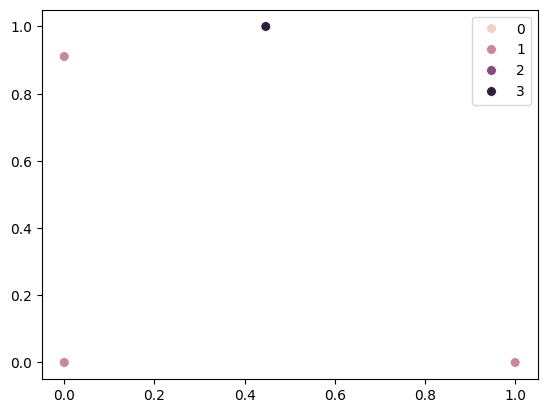

In [61]:
X = tfidf_scaled
sns.scatterplot(x = X[:,0], y = X[:,1], hue = kmeans.labels_, s=50) ;

### AI Consultation

**This next section leverages the help of AI to create a PCA analysis of the same dataframe:**

In [62]:
from sklearn.decomposition import PCA

# pca
pca = PCA(n_components = 2, random_state = 42)
X = pca.fit_transform(tfidf_scaled)

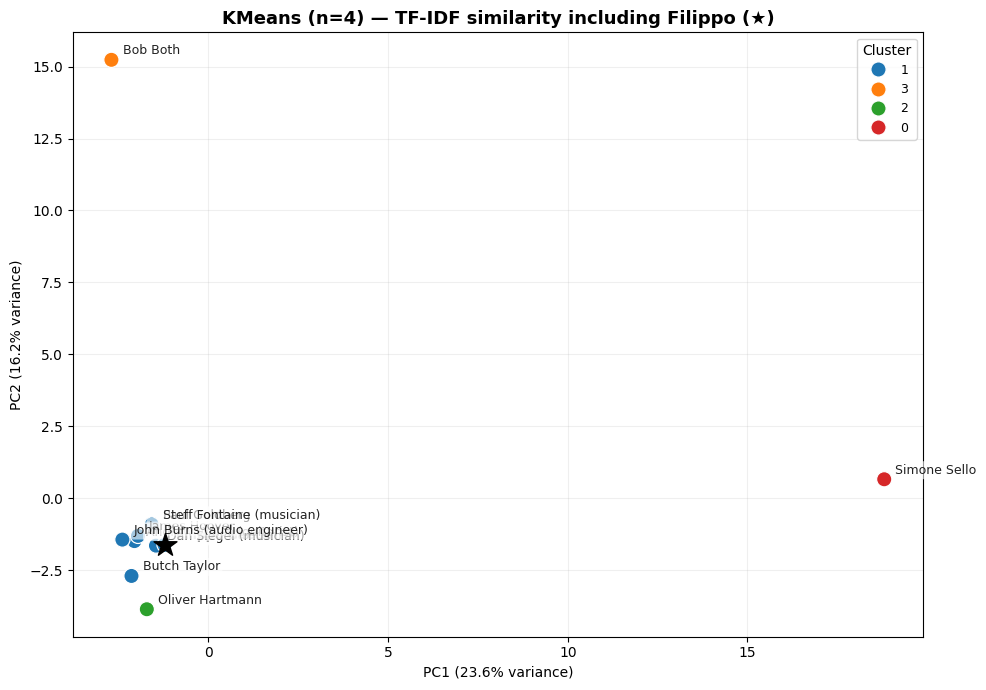

In [63]:
# ── Plot
names = df_sentiment_all['name'].reset_index(drop=True)
filippo_idx = df_sentiment_all[df_sentiment_all['name'] == fillipo_orig].index[0]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    x=X[:, 0], y=X[:, 1],
    hue=kmeans.labels_.astype(str),
    s=120, ax=ax, palette='tab10', zorder=3
)

# Filippo as a distinct star marker
ax.scatter(
    X[filippo_idx, 0], X[filippo_idx, 1],
    s=300, color='black', zorder=5, marker='*'
)
ax.annotate(
    f"{fillipo_orig} ★",
    (X[filippo_idx, 0], X[filippo_idx, 1]),
    textcoords='offset points', xytext=(8, 4),
    fontsize=9, fontweight='bold', color='black',
    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
)

# Labels for all other people
for i, name in enumerate(names):
    if i == filippo_idx:
        continue  # already labeled above
    ax.annotate(
        name,
        (X[i, 0], X[i, 1]),
        textcoords='offset points', xytext=(8, 4),
        fontsize=9, color='#222222',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none')
    )

ax.set_title("KMeans (n=4) — TF-IDF similarity including Filippo (★)", fontsize=13, fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=10)
ax.legend(title='Cluster', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Part 3)


**This next section was also created with the help of AI and will be refactored shortly.**

In [70]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.metrics.pairwise import cosine_similarity

# ── Dropdown + free-text entry
name_input = widgets.Combobox(
    placeholder='Type or select a name...',
    options=sorted(df_sentiment_all['name'].tolist()),
    description='Person:',
    ensure_option=False,
    layout=widgets.Layout(width='400px')
)
run_button = widgets.Button(
    description='Find 10 Closest',
    button_style='primary',
    layout=widgets.Layout(width='180px')
)
output = widgets.Output()

def find_closest(b):
    with output:
        clear_output(wait=True)
        query_name = name_input.value.strip()

        if not query_name:
            print("⚠️  Please enter or select a name.")
            return

        # ── Check if name is in dataset
        match = df_sentiment_all[
            df_sentiment_all['name'].str.lower() == query_name.lower()
        ]

        if match.empty:
            # ── Name not in dataset: fetch from Wikipedia on the fly
            print(f"'{query_name}' not in dataset — fetching from Wikipedia...")
            try:
                page = wikip.page(query_name)
                if not page.exists():
                    print(f"⚠️  No Wikipedia page found for '{query_name}'. Check the spelling.")
                    return
                raw_text = page.text
                query_clean = (
                    raw_text.lower()
                    .replace("\n", " ")
                    .replace("\'s", '')
                    .replace('\'', '')
                    .replace("(", "")
                    .replace(")", "")
                    .replace('"', "")
                )
                query_vector = results_tf_idf_all.transform([query_clean])
                query_vector = scaler.transform(query_vector.toarray())
            except Exception as e:
                print(f"⚠️  Wikipedia fetch failed: {e}")
                return
        else:
            # ── Name is in dataset: use existing scaled TF-IDF row
            idx = match.index[0]
            query_vector = tfidf_scaled[idx].reshape(1, -1)

        # ── Cosine similarity against all 11 people
        sims = cosine_similarity(query_vector, tfidf_scaled).flatten()

        # ── Build results dataframe
        results = df_sentiment_all[['name']].copy().reset_index(drop=True)
        results['similarity'] = sims

        # Exclude the query person themselves
        results = results[results['name'].str.lower() != query_name.lower()]

        top10 = (
            results
            .sort_values('similarity', ascending=False)
            .head(10)
            .reset_index(drop=True)
        )
        top10.index += 1  # rank from 1

        # ── Display
        print(f"\n10 closest individuals to: {query_name}\n")
        display(
            top10[['name', 'similarity']]
            .rename(columns={'name': 'Name', 'similarity': 'Cosine Similarity'})
            .style
            .format({'Cosine Similarity': '{:.4f}'})
            .bar(subset=['Cosine Similarity'], color='#5B8DB8')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'left')]},
                {'selector': 'td', 'props': [('font-size', '12px')]}
            ])
        )

run_button.on_click(find_closest)
display(widgets.VBox([
    widgets.HTML("<h3>Wikipedia Similarity (Top 10)</h3>"),
    widgets.HBox([name_input, run_button]),
    output
]))

# 👩🏼‍💻 Future Development

In [66]:
# gather sentences
full_sentences = orig_dat['text'].tolist()

# initialize tf-idf
full_tf_idf_matrix = TfidfVectorizer(stop_words='english')
full_tf_idf = full_tf_idf_matrix.fit_transform(full_sentences)

# get words?
full_results_tf_idf = pd.DataFrame(
    data = full_tf_idf.toarray(),
    columns = full_tf_idf_matrix.get_feature_names_out()
)

pd.set_option('display.max_rows', 200)
full_results_tf_idf

KeyboardInterrupt: 